# 01 — Data Acquisition & EDA
**ZivaBasa MVP (Kaggle-Data Phase)**

This notebook:
1. Loads the three proxy Kaggle datasets (Employment, Skills, Productivity task heads)
2. Runs data-quality checks (missing values, duplicates, dtypes)
3. Produces descriptive statistics, correlations, and distribution plots per dataset
4. Documents known cross-dataset alignment limitations (see project README, Section 7)

> ⚠️ These are proxy datasets standing in for real banking-sector data. Findings here are
> methodological (does the pipeline work?), not empirical (are these real workforce dynamics?).

**Output:** lightly-validated raw dataframes saved to `data/raw/` (as parquet) for
`02_feature_engineering.ipynb` to consume.


In [13]:
# --- Setup ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

RAW_DIR = "../data/raw"
os.makedirs(RAW_DIR, exist_ok=True)

print("pandas:", pd.__version__)


pandas: 2.2.2


## 1. Data Acquisition

Three datasets, one per task head. Download via the Kaggle API (recommended) or manually place
CSVs in `data/raw/` with the filenames below.

```bash
# Kaggle API setup (one-time): place kaggle.json in ~/.kaggle/, then:
pip install kaggle --break-system-packages
kaggle datasets download -d khushikyad001/ai-automation-risk-by-job-role -p ../data/raw --unzip
kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset -p ../data/raw --unzip
kaggle datasets download -d algozee/future-of-work-in-the-age-of-ai-20202026 -p ../data/raw --unzip
```

If you downloaded manually from kaggle.com, just drop the CSVs into `data/raw/` and update the
filenames in the cell below to match.


In [14]:
# --- Expected raw filenames (adjust to match what you actually downloaded) ---
FILES = {
    "employment": "ai_automation_risk_dataset.csv",   # Employment / Automation Risk task head
    "skills": "WA_Fn-UseC_-HR-Employee-Attrition.csv",  # Skills / Readiness task head
    "productivity": "ai_job_replacement_2020_2026_v2.csv",  # Productivity / AI Adoption task head
}

def load_csv(key):
    path = os.path.join(RAW_DIR, FILES[key])
    if not os.path.exists(path):
        print(f"[MISSING] {path} — download it before continuing (see markdown cell above).")
        return None
    df = pd.read_csv(path)
    print(f"[{key}] loaded {df.shape[0]:,} rows x {df.shape[1]} cols from {FILES[key]}")
    return df

df_employment = load_csv("employment")
df_skills = load_csv("skills")
df_productivity = load_csv("productivity")


[employment] loaded 3,000 rows x 25 cols from ai_automation_risk_dataset.csv
[skills] loaded 1,470 rows x 35 cols from WA_Fn-UseC_-HR-Employee-Attrition.csv
[productivity] loaded 15,000 rows x 20 cols from ai_job_replacement_2020_2026_v2.csv


## 2. Quick Structural Overview

For each dataset: shape, dtypes, first rows. This is the first sanity check before anything else —
confirm you actually got the columns you expect.


In [15]:
def overview(df, name):
    if df is None:
        print(f"[{name}] not loaded, skipping.")
        return
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print("\nDtypes:\n", df.dtypes)
    display(df.head())
    print("\n" + "-"*80 + "\n")

overview(df_employment, "Employment (automation risk)")
overview(df_skills, "Skills (IBM HR attrition)")
overview(df_productivity, "Productivity (future of work / AI adoption)")


=== Employment (automation risk) ===
Shape: (3000, 25)

Dtypes:
 job_role                            object
industry                            object
avg_salary_usd                       int64
experience_required_years            int64
education_level                     object
task_repetition_level              float64
creativity_requirement             float64
physical_labor_level               float64
analytical_complexity              float64
social_interaction_level           float64
ai_tool_availability                object
ai_tool_maturity_score             float64
percent_tasks_automatable          float64
job_growth_rate                    float64
skill_complexity_score             float64
regulation_strictness_level        float64
ethical_risk_level                 float64
communication_requirement          float64
domain_specific_knowledge_level    float64
team_collaboration_level           float64
ai_dependency_current              float64
ai_dependency_future            

,job_role,industry,avg_salary_usd,experience_required_years,education_level,task_repetition_level,creativity_requirement,physical_labor_level,analytical_complexity,social_interaction_level,ai_tool_availability,ai_tool_maturity_score,percent_tasks_automatable,job_growth_rate,skill_complexity_score,regulation_strictness_level,ethical_risk_level,communication_requirement,domain_specific_knowledge_level,team_collaboration_level,ai_dependency_current,ai_dependency_future,training_hours_needed,job_demand_index,automation_risk_score
0,Graphic Designer,Manufacturing,79768,0,Master,0.547871,0.342500,0.380444,0.654976,0.258830,Gemini,0.945982,0.729611,-0.092463,0.236099,0.680929,0.803649,0.721463,0.386295,0.707338,0.379348,0.396058,317,0.305426,0.745462
1,UX Designer,Retail,78128,11,Master,0.023961,0.076849,0.056515,0.061107,0.748744,Claude,0.324408,0.504684,-0.072548,0.037372,0.881563,0.091322,0.049990,0.498384,0.506152,0.612060,0.671260,21,0.010498,0.419443
2,Product Manager,Education,113123,6,High School,0.764220,0.392944,0.677674,0.436737,0.163962,Claude,0.347507,0.593449,0.008407,0.472268,0.730612,0.874978,0.203518,0.160583,0.530658,0.926217,0.665344,55,0.165525,0.563108
3,Plumber,Education,138255,2,Bachelor,0.580914,0.669926,0.328202,0.913109,0.846632,Claude,0.870638,0.927684,0.007696,0.382409,0.952344,0.680560,0.621212,0.196197,0.449946,0.890983,0.309024,146,0.724731,0.801213
4,Doctor,Marketing,33174,5,Bachelor,0.625590,0.469890,0.467776,0.791285,0.131904,AutoGPT,0.129043,0.393783,0.143076,0.835886,0.886246,0.927072,0.477470,0.602069,0.584847,0.169667,0.188985,310,0.004424,0.253071



--------------------------------------------------------------------------------

=== Skills (IBM HR attrition) ===
Shape: (1470, 35)

Dtypes:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRati

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



--------------------------------------------------------------------------------

=== Productivity (future of work / AI adoption) ===
Shape: (15000, 20)

Dtypes:
 job_id                           int64
job_role                        object
industry                        object
country                         object
year                             int64
automation_risk_percent        float64
ai_replacement_score           float64
skill_gap_index                float64
salary_before_usd              float64
salary_after_usd               float64
salary_change_percent          float64
skill_demand_growth_percent    float64
remote_feasibility_score       float64
ai_adoption_level              float64
education_requirement_level      int64
automation_risk_category        object
skill_transition_pressure      float64
wage_volatility_index          float64
reskilling_urgency_score       float64
ai_disruption_intensity        float64
dtype: object


,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910



--------------------------------------------------------------------------------



## 3. Data Quality Checks

Missing values, duplicate rows, and constant/near-constant columns — per dataset. Flag issues
here rather than silently handling them; the fixes belong in `02_feature_engineering.ipynb`.


In [16]:
def quality_report(df, name):
    if df is None:
        return None
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    }).sort_values("missing_pct", ascending=False)

    n_dupes = df.duplicated().sum()
    print(f"=== {name} — Data Quality ===")
    print(f"Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)")
    display(report)
    print("\n" + "-"*80 + "\n")
    return report

qr_employment = quality_report(df_employment, "Employment")
qr_skills = quality_report(df_skills, "Skills")
qr_productivity = quality_report(df_productivity, "Productivity")


=== Employment — Data Quality ===
Duplicate rows: 0 (0.00%)


,dtype,missing_count,missing_pct,n_unique
ai_tool_availability,object,425,14.17,6
job_role,object,0,0.00,20
job_growth_rate,float64,0,0.00,3000
job_demand_index,float64,0,0.00,3000
training_hours_needed,int64,0,0.00,489
ai_dependency_future,float64,0,0.00,3000
ai_dependency_current,float64,0,0.00,3000
team_collaboration_level,float64,0,0.00,3000
domain_specific_knowledge_level,float64,0,0.00,3000
communication_requirement,float64,0,0.00,3000



--------------------------------------------------------------------------------

=== Skills — Data Quality ===
Duplicate rows: 0 (0.00%)


,dtype,missing_count,missing_pct,n_unique
Age,int64,0,0.0,43
StandardHours,int64,0,0.0,1
NumCompaniesWorked,int64,0,0.0,10
Over18,object,0,0.0,1
OverTime,object,0,0.0,2
PercentSalaryHike,int64,0,0.0,15
PerformanceRating,int64,0,0.0,2
RelationshipSatisfaction,int64,0,0.0,4
StockOptionLevel,int64,0,0.0,4
MonthlyIncome,int64,0,0.0,1349



--------------------------------------------------------------------------------

=== Productivity — Data Quality ===
Duplicate rows: 0 (0.00%)


,dtype,missing_count,missing_pct,n_unique
job_id,int64,0,0.0,15000
job_role,object,0,0.0,10
reskilling_urgency_score,float64,0,0.0,13353
wage_volatility_index,float64,0,0.0,2432
skill_transition_pressure,float64,0,0.0,9771
automation_risk_category,object,0,0.0,3
education_requirement_level,int64,0,0.0,5
ai_adoption_level,float64,0,0.0,7750
remote_feasibility_score,float64,0,0.0,7324
skill_demand_growth_percent,float64,0,0.0,4190



--------------------------------------------------------------------------------



## 4. Descriptive Statistics

Numeric summary stats per dataset — range, mean, std, skew. Useful for spotting outliers and
scale mismatches before feature engineering (e.g. salary in thousands vs. a 1–5 satisfaction score).


In [17]:
def describe_numeric(df, name):
    if df is None:
        return
    num_df = df.select_dtypes(include=[np.number])
    print(f"=== {name} — Numeric Summary ===")
    display(num_df.describe().T.assign(
        skew=num_df.skew()
    ).round(2))
    print("\n" + "-"*80 + "\n")

describe_numeric(df_employment, "Employment")
describe_numeric(df_skills, "Skills")
describe_numeric(df_productivity, "Productivity")


=== Employment — Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max,skew
avg_salary_usd,3000.0,105939.87,43620.82,30028.0,67498.25,107061.50,143663.50,179967.00,-0.02
experience_required_years,3000.0,7.08,4.30,0.0,3.00,7.00,11.00,14.00,-0.03
task_repetition_level,3000.0,0.50,0.29,0.0,0.24,0.49,0.76,1.00,0.03
creativity_requirement,3000.0,0.51,0.29,0.0,0.27,0.52,0.75,1.00,-0.06
physical_labor_level,3000.0,0.51,0.29,0.0,0.27,0.51,0.76,1.00,-0.02
analytical_complexity,3000.0,0.51,0.29,0.0,0.26,0.52,0.76,1.00,-0.05
social_interaction_level,3000.0,0.50,0.29,0.0,0.25,0.50,0.74,1.00,-0.00
ai_tool_maturity_score,3000.0,0.50,0.29,0.0,0.26,0.51,0.75,1.00,-0.03
percent_tasks_automatable,3000.0,0.49,0.29,0.0,0.24,0.49,0.75,1.00,0.03
job_growth_rate,3000.0,0.02,0.07,-0.1,-0.04,0.02,0.08,0.15,0.04



--------------------------------------------------------------------------------

=== Skills — Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max,skew
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0,0.41
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0,-0.00
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0,0.96
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0,-0.29
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0,0.00
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0,0.02
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0,-0.32
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0,-0.03
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0,-0.50
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0,1.03



--------------------------------------------------------------------------------

=== Productivity — Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max,skew
job_id,15000.0,7499.50,4330.27,0.00,3749.75,7499.50,11249.25,14999.00,0.00
year,15000.0,2023.00,2.00,2020.00,2021.00,2023.00,2025.00,2026.00,0.00
automation_risk_percent,15000.0,46.18,21.66,5.00,28.79,46.24,63.60,94.98,0.03
ai_replacement_score,15000.0,46.16,22.35,4.01,28.36,45.68,62.71,113.07,0.17
skill_gap_index,15000.0,50.00,28.81,0.00,25.17,49.93,75.03,99.98,0.00
salary_before_usd,15000.0,89771.38,34522.13,30003.69,60127.23,89533.05,119823.84,149984.06,0.01
salary_after_usd,15000.0,89870.63,35897.59,19022.67,59223.46,88787.33,118432.97,191961.21,0.16
salary_change_percent,15000.0,0.11,10.03,-38.37,-6.64,0.15,6.69,36.92,0.02
skill_demand_growth_percent,15000.0,5.02,9.96,-31.88,-1.66,4.96,11.73,49.79,0.01
remote_feasibility_score,15000.0,54.90,25.86,10.01,32.52,54.78,77.40,99.99,0.01



--------------------------------------------------------------------------------



## 5. Categorical Overview

Value counts for categorical columns — job roles, departments, industries. This tells you what
join keys (if any) might realistically bridge the three datasets, and confirms there's no hidden
target leakage sitting in an unexpected column.


In [18]:
def categorical_overview(df, name, max_cats=15):
    if df is None:
        return
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    print(f"=== {name} — Categorical Columns ===")
    for col in cat_cols:
        n_unique = df[col].nunique()
        print(f"\n{col} ({n_unique} unique values)")
        if n_unique <= max_cats:
            display(df[col].value_counts())
        else:
            display(df[col].value_counts().head(max_cats))
    print("\n" + "-"*80 + "\n")

categorical_overview(df_employment, "Employment")
categorical_overview(df_skills, "Skills")
categorical_overview(df_productivity, "Productivity")


=== Employment — Categorical Columns ===

job_role (20 unique values)


job_role
Customer Support        169
Consultant              169
Product Manager         164
Doctor                  164
HR Specialist           162
Software Engineer       159
Data Analyst            159
Teacher                 157
Accountant              153
Marketing Specialist    152
Civil Engineer          150
UX Designer             147
Nurse                   146
Sales Manager           146
Business Analyst        144
Name: count, dtype: int64


industry (10 unique values)


industry
Manufacturing    339
Legal            318
Finance          304
Tech             303
Energy           298
Retail           297
Construction     293
Marketing        292
Healthcare       286
Education        270
Name: count, dtype: int64


education_level (4 unique values)


...


country (9 unique values)


country
Singapore    1748
USA          1731
UK           1716
Brazil       1659
Australia    1642
Canada       1640
India        1640
Japan        1638
Germany      1586
Name: count, dtype: int64


automation_risk_category (3 unique values)


automation_risk_category
Medium    6464
High      4496
Low       4040
Name: count, dtype: int64


--------------------------------------------------------------------------------



## 6. Distributions

Histograms for key numeric fields per dataset. Adjust `cols_to_plot` per dataset once you've
confirmed actual column names from Section 2 — these are placeholders based on typical schemas
for each source.


[Employment] none of the requested columns were found — check column names.


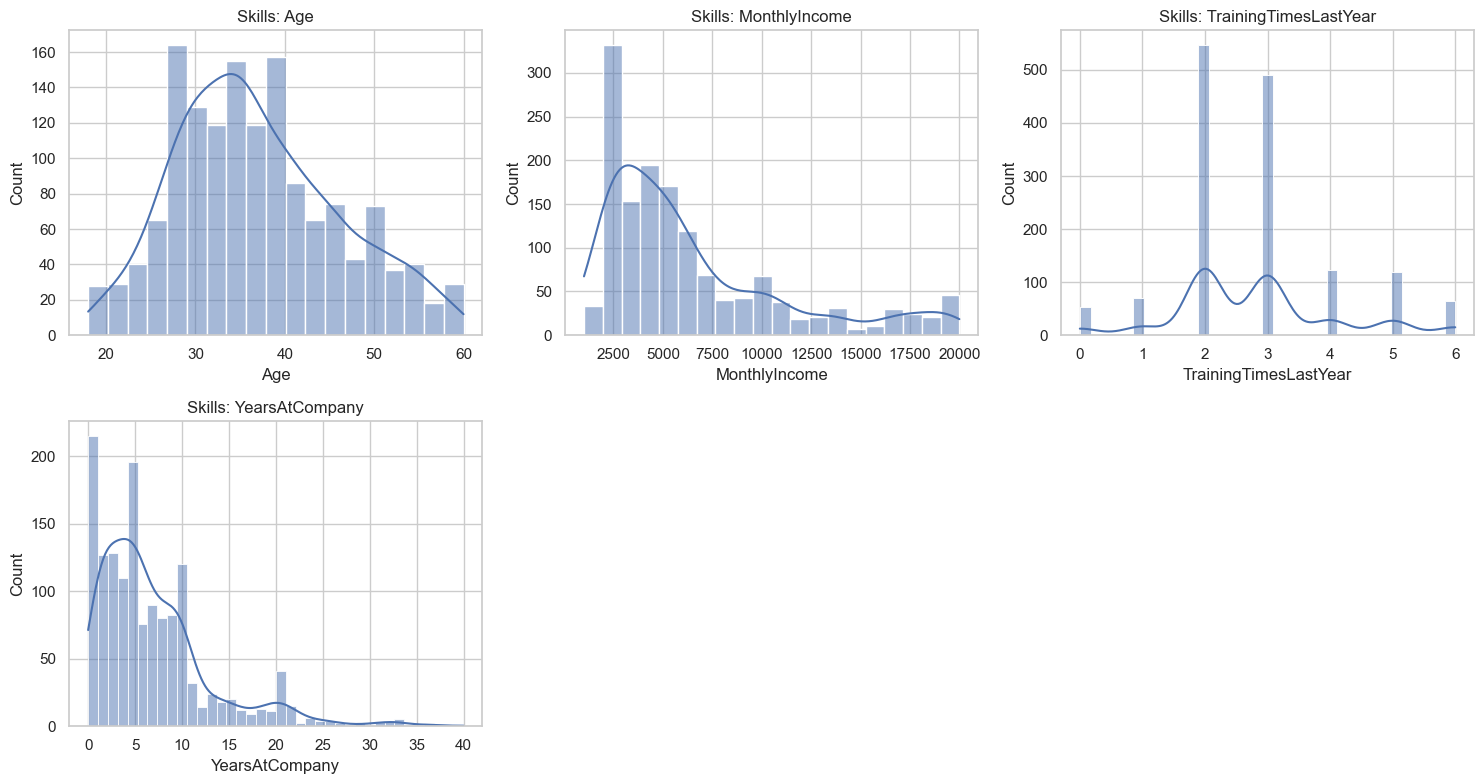

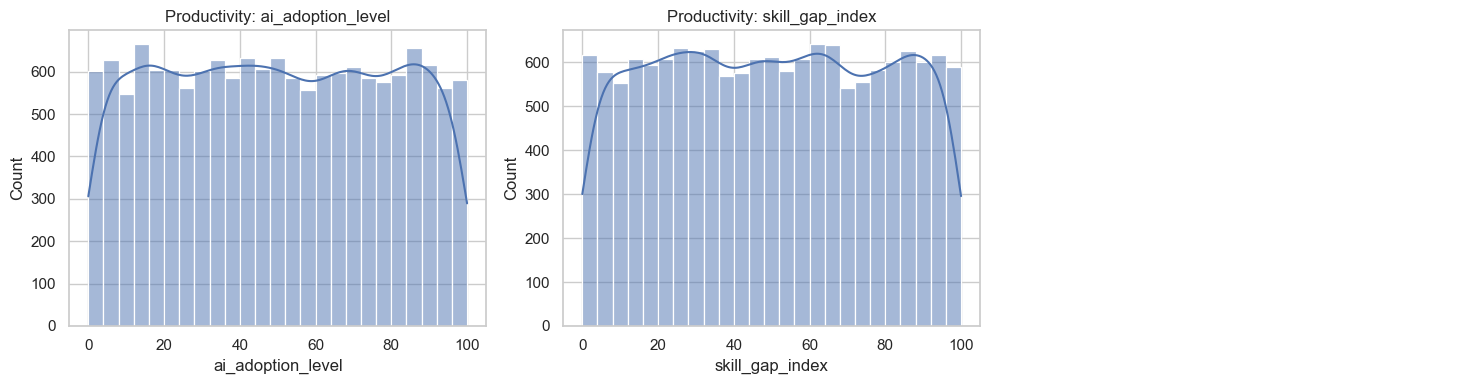

In [19]:
def plot_distributions(df, cols, name, ncols=3):
    if df is None:
        return
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print(f"[{name}] none of the requested columns were found — check column names.")
        return
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f"{name}: {col}")
    for j in range(len(cols), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

# Adjust these to the real column names once confirmed in Section 2
plot_distributions(df_employment, ["automation_risk", "risk_score", "salary"], "Employment")
plot_distributions(df_skills, ["Age", "MonthlyIncome", "TrainingTimesLastYear", "YearsAtCompany"], "Skills")
plot_distributions(df_productivity, ["ai_adoption_level", "skill_gap_index", "salary_trend"], "Productivity")


## 7. Correlation Analysis

Correlation heatmap per dataset (numeric columns only). Look for: (a) features highly correlated
with your intended target — potential leakage, (b) redundant feature pairs to collapse during
feature engineering.


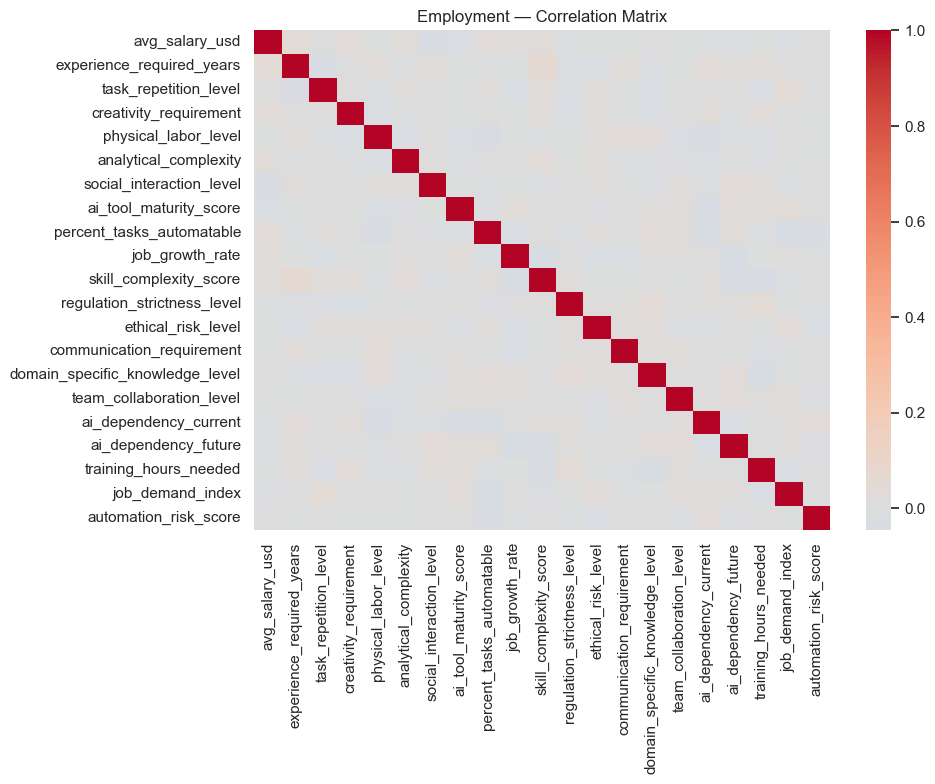

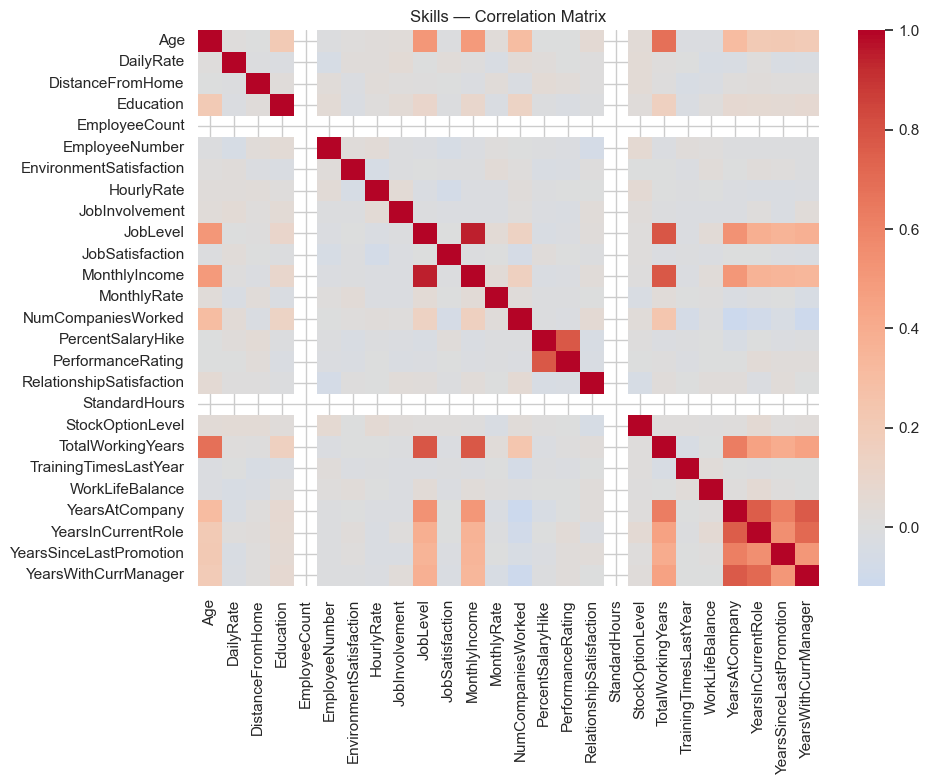

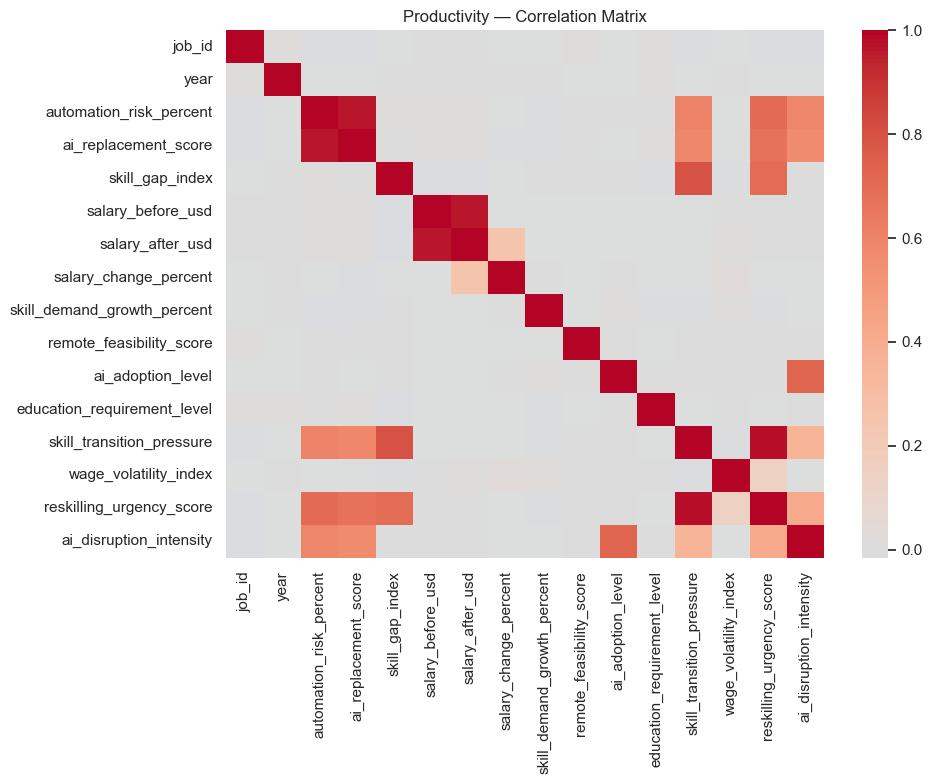

In [20]:
def correlation_heatmap(df, name):
    if df is None:
        return
    num_df = df.select_dtypes(include=[np.number])
    if num_df.shape[1] < 2:
        print(f"[{name}] not enough numeric columns for a correlation matrix.")
        return
    plt.figure(figsize=(10, 8))
    sns.heatmap(num_df.corr(), annot=False, cmap="coolwarm", center=0)
    plt.title(f"{name} — Correlation Matrix")
    plt.tight_layout()
    plt.show()

correlation_heatmap(df_employment, "Employment")
correlation_heatmap(df_skills, "Skills")
correlation_heatmap(df_productivity, "Productivity")


## 8. Cross-Dataset Alignment Check

These three datasets are **not** the same population (see README, Section 7 — Known Limitations).
This cell just documents what candidate join/alignment keys exist (role, industry, department
naming) so `02_feature_engineering.ipynb` knows what it's working with — it does **not** attempt
a row-level join.


In [21]:
candidate_keys = {
    "employment": [c for c in (df_employment.columns if df_employment is not None else [])
                   if any(k in c.lower() for k in ["role", "job", "occupation", "industry"])],
    "skills": [c for c in (df_skills.columns if df_skills is not None else [])
               if any(k in c.lower() for k in ["role", "job", "department", "industry"])],
    "productivity": [c for c in (df_productivity.columns if df_productivity is not None else [])
                      if any(k in c.lower() for k in ["role", "job", "industry", "sector"])],
}

print("Candidate alignment columns per dataset (schema-level only, not a real join key):")
for k, v in candidate_keys.items():
    print(f"  {k}: {v}")

print("""
NOTE: Because these datasets have no shared entity ID, any 'alignment' in
02_feature_engineering.ipynb will be at the feature-schema level (e.g. mapping each dataset's
job-role/industry categories onto a shared taxonomy), not a row-level merge. Document this
explicitly wherever these features are used downstream.
""")


Candidate alignment columns per dataset (schema-level only, not a real join key):
  employment: ['job_role', 'industry', 'job_growth_rate', 'job_demand_index']
  skills: ['Department', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'YearsInCurrentRole']
  productivity: ['job_id', 'job_role', 'industry']

NOTE: Because these datasets have no shared entity ID, any 'alignment' in
02_feature_engineering.ipynb will be at the feature-schema level (e.g. mapping each dataset's
job-role/industry categories onto a shared taxonomy), not a row-level merge. Document this
explicitly wherever these features are used downstream.



## 9. Save Validated Raw Data

Save each dataframe to parquet (faster + preserves dtypes better than CSV) so
`02_feature_engineering.ipynb` has a clean, consistent starting point. No transformation happens
here — this is a checkpoint, not a cleaning step.


In [23]:
def save_checkpoint(df, name):
    if df is None:
        print(f"[{name}] not loaded, nothing to save.")
        return
    out_path = os.path.join("../data/processed", f"{name}_checked.parquet")
    df.to_parquet(out_path, index=False)
    print(f"[{name}] saved checkpoint -> {out_path}")

save_checkpoint(df_employment, "employment")
save_checkpoint(df_skills, "skills")
save_checkpoint(df_productivity, "productivity")


[employment] saved checkpoint -> ../data/processed\employment_checked.parquet
[skills] saved checkpoint -> ../data/processed\skills_checked.parquet
[productivity] saved checkpoint -> ../data/processed\productivity_checked.parquet


## 10. Summary — Carry Forward to Notebook 02

Fill this in after running the notebook, before moving to feature engineering:

- [ ] Confirmed actual column names for each dataset (update Sections 6 placeholders if needed)
- [ ] Target variable identified per task head (Employment / Productivity / Skills)
- [ ] Missing-value strategy decided per column (drop / impute / flag)
- [ ] Categorical encoding strategy decided (one-hot vs. target encoding vs. embedding)
- [ ] Outliers noted (from Section 4 skew values) — decide clip vs. keep
- [ ] Cross-dataset alignment approach confirmed (schema-level mapping, not row-level join)
